In [42]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import gerrychain
import plotly.express as px
pd.set_option('display.max_columns', None)
import os
os.chdir("/Users/samstephenson/Downloads/capy-bara")


Note: the chicago metro area boundaries unchanged btw 2010 and 2020
2010 Analysis

In [43]:
tract= pd.read_csv("outputs/tracts_in_cbsa/white_black.csv")
tract["year"] = tract["filename"].str.extract(r"(\d{4})").astype(int)
tract["cbsa_code"] = (
    tract["filename"]
      .str.extract(rf"tracts_in_cbsa_(\d+)")[0]
      .astype(int)
)

bg = pd.read_csv("outputs/block_groups_in_cbsa/white_black.csv")
bg["year"] = bg["filename"].str.extract(r"(\d{4})").astype(int)
bg["cbsa_code"] = (
    bg["filename"]
      .str.extract(rf"block_groups_in_cbsa_(\d+)")[0]
      .astype(int)
)
block = pd.read_csv("outputs/blocks_in_cbsa/white_black.csv")
block["year"] = block["filename"].str.extract(r"(\d{4})").astype(int)
block["cbsa_code"] = (
    block["filename"]
      .str.extract(rf"blocks_in_cbsa_(\d+)")[0]
      .astype(int)
)

In [44]:
tract = tract[(tract["year"] == 2020) & (tract["cbsa_code"] == 16980)]
block = block[(block["year"] == 2020) & (block["cbsa_code"] == 16980)]
bg = bg[(bg["year"] == 2020) & (bg["cbsa_code"] == 16980)]

In [45]:
bg["half_edge_1"].iloc[0]

np.float64(0.796690272481767)

In [46]:
metrics = [
    "Capy",
    "dissimilarity",
    "Moran_A"]


bg_values = [
    bg["half_edge_1"].iloc[0],
    bg["dissimilarity_1"].iloc[0],
    bg["moran_A"].iloc[0]]

tract_values = [
    tract["half_edge_1"].iloc[0],
    tract["dissimilarity_1"].iloc[0],
    tract["moran_A"].iloc[0]
    ]

block_values = [
    block["half_edge_1"].iloc[0],
    block["dissimilarity_1"].iloc[0],
    block["moran_A"].iloc[0]
    ]

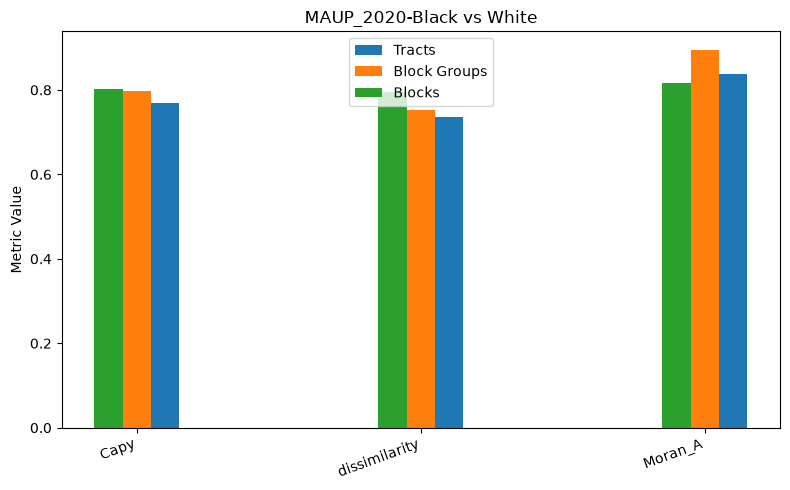

In [47]:
x = np.arange(len(metrics))
width = 0.1

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x + width, tract_values, width, label="Tracts")
ax.bar(x, bg_values, width, label="Block Groups")
ax.bar(x-width, block_values, width, label="Blocks")


ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_ylabel("Metric Value")
ax.set_title("MAUP_2020-Black vs White")
ax.legend()

plt.tight_layout()
plt.show()

In [48]:
metrics = [
    "edge",
    "half_edge",
    "dissimilarity",
    "moran",
]

block_values = [
    block_black["edge_lam_1_angle_1"][0],
    block_black["half_edge_lam_1_angle_1"][0],
    block_black["dissimilarity"][0],
    block_black["moran"][0]
    ]

bg_values = [
    bg_black["edge_lam_1_angle_1"][0],
    bg_black["half_edge_lam_1_angle_1"][0],
    bg_black["dissimilarity"][0],
    bg_black["moran"][0],
]

tract_values = [
    tract_black["edge_lam_1_angle_1"][0],
    tract_black["half_edge_lam_1_angle_1"][0],
    tract_black["dissimilarity"][0],
    tract_black["moran"][0]
    ]

NameError: name 'block_black' is not defined

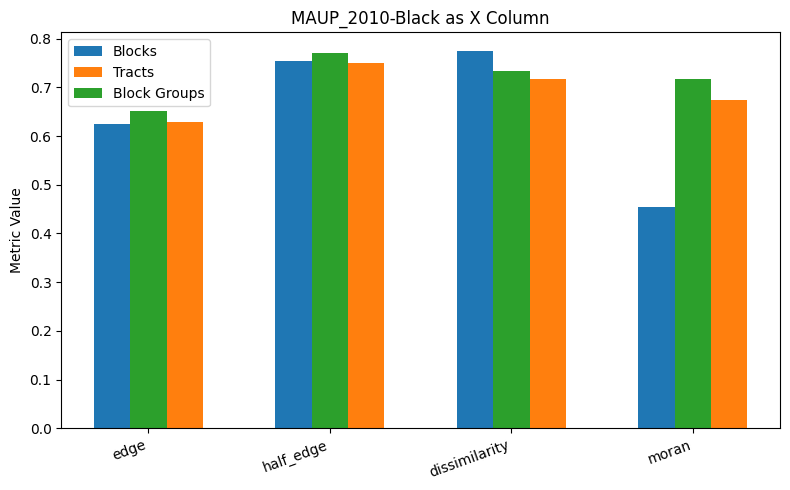

In [ ]:
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width, block_values, width, label="Blocks")
ax.bar(x + width, tract_values, width, label="Tracts")
ax.bar(x, bg_values, width, label="Block Groups")

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_ylabel("Metric Value")
ax.set_title("MAUP_2010-Black as X Column")
ax.legend()

plt.tight_layout()
plt.show()

2020

In [ ]:
tract_black = pd.read_csv("outputs/tract_white_black_chicago_2020.csv")
tract_poc = pd.read_csv("outputs/tract_white_poc_chicago_2020.csv")
bg_black = pd.read_csv("outputs/bg_white_black_chicago_2020.csv")
bg_poc = pd.read_csv("outputs/bg_white_poc_chicago_2020.csv")
block_black = pd.read_csv("outputs/block_white_black_chicago_2020.csv")
block_poc = pd.read_csv("outputs/block_white_poc_chicago_2020.csv")

EmptyDataError: No columns to parse from file

In [ ]:
metrics = [
    "edge",
    "half_edge",
    "dissimilarity",
    "moran",
]
block_values = [
    block_poc["edge_lam_1_angle_1"][0],
    block_poc["half_edge_lam_1_angle_1"][0],
    block_poc["dissimilarity"][0],
    block_poc["moran"][0]
    ]

bg_values = [
    bg_poc["edge_lam_1_angle_1"][0],
    bg_poc["half_edge_lam_1_angle_1"][0],
    bg_poc["dissimilarity"][0],
    bg_poc["moran"][0],
]

tract_values = [
    tract_poc["edge_lam_1_angle_1"][0],
    tract_poc["half_edge_lam_1_angle_1"][0],
    tract_poc["dissimilarity"][0],
    tract_poc["moran"][0]
    ]

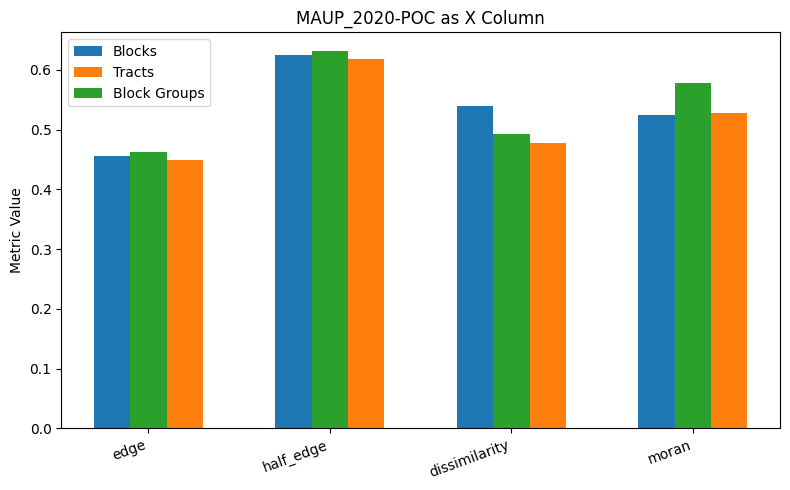

In [ ]:
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width, block_values, width, label="Blocks")
ax.bar(x + width, tract_values, width, label="Tracts")
ax.bar(x, bg_values, width, label="Block Groups")

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_ylabel("Metric Value")
ax.set_title("MAUP_2020-POC as X Column")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
metrics = [
    "edge",
    "half_edge",
    "dissimilarity",
    "moran",
]
block_values = [
    block_black["edge_lam_1_angle_1"][0],
    block_black["half_edge_lam_1_angle_1"][0],
    block_black["dissimilarity"][0],
    block_black["moran"][0]
    ]

bg_values = [
    bg_black["edge_lam_1_angle_1"][0],
    bg_black["half_edge_lam_1_angle_1"][0],
    bg_black["dissimilarity"][0],
    bg_black["moran"][0],
]

tract_values = [
    tract_black["edge_lam_1_angle_1"][0],
    tract_black["half_edge_lam_1_angle_1"][0],
    tract_black["dissimilarity"][0],
    tract_black["moran"][0]
    ]

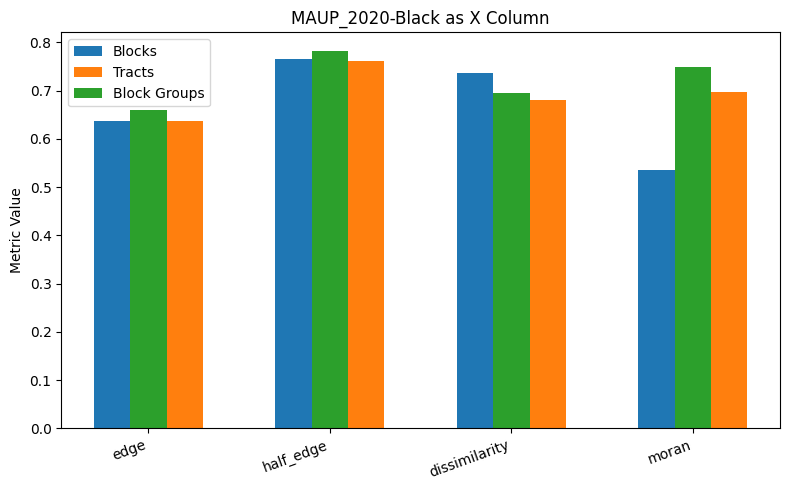

In [ ]:
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width, block_values, width, label="Blocks")
ax.bar(x + width, tract_values, width, label="Tracts")
ax.bar(x, bg_values, width, label="Block Groups")

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_ylabel("Metric Value")
ax.set_title("MAUP_2020-Black as X Column")
ax.legend()

plt.tight_layout()
plt.show()